In [7]:
import os
import sys



#la racine du projet
ROOT_DIR = os.path.abspath("..")
sys.path.append(ROOT_DIR)

from model.mctnet import MCTNet

#  1: Imports and Setup

In [8]:
# CELL 1: Imports and Setup
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("="*70)
print("PART 5: MCTNet MODEL IMPLEMENTATION")
print("="*70)
print("\nPaper Reference:")
print("  - Section 2.3: MCTNet Architecture (Figure 3)")
print("  - Section 2.3.1: Transformer Sub-module + ALPE (Figures 4-5)")
print("  - Section 2.3.2: CNN Sub-module (Figure 6)")
print("  - Table 3: Hyperparameters")
print("="*70)

PyTorch version: 2.7.1+cpu
Using device: cpu
PART 5: MCTNet MODEL IMPLEMENTATION

Paper Reference:
  - Section 2.3: MCTNet Architecture (Figure 3)
  - Section 2.3.1: Transformer Sub-module + ALPE (Figures 4-5)
  - Section 2.3.2: CNN Sub-module (Figure 6)
  - Table 3: Hyperparameters


# 2: Load Preprocessed Data (UPDATED for balanced data)

In [9]:
# CELL 2: Load Preprocessed Data (FIXED)

print("\n" + "="*70)
print("LOADING PREPROCESSED DATA")
print("="*70)

# USE THE PREPROCESSED DIRECTORY (with vegetation indices)
PROCESSED_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed"

# Load data with vegetation indices (13 bands)
X = np.load(os.path.join(PROCESSED_DIR, 'X.npy'))
y = np.load(os.path.join(PROCESSED_DIR, 'y.npy'))
masks = np.load(os.path.join(PROCESSED_DIR, 'masks.npy'))

# Load indices
train_idx = np.load(os.path.join(PROCESSED_DIR, 'train_indices.npy'))
val_idx = np.load(os.path.join(PROCESSED_DIR, 'val_indices.npy'))
test_idx = np.load(os.path.join(PROCESSED_DIR, 'test_indices.npy'))

# Load metadata
with open(os.path.join(PROCESSED_DIR, 'metadata.pkl'), 'rb') as f:
    metadata = pickle.load(f)

print(f" Loaded data from: {PROCESSED_DIR}")
print(f"\nX shape: {X.shape} (samples, time_steps={X.shape[1]}, bands={X.shape[2]})")
print(f"y shape: {y.shape}")
print(f"masks shape: {masks.shape}")
print(f"Classes: {metadata['crop_names']}")
print(f"Training samples: {len(train_idx)}")
print(f"Validation samples: {len(val_idx)}")
print(f"Test samples: {len(test_idx)}")


LOADING PREPROCESSED DATA
 Loaded data from: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed

X shape: (10487, 36, 13) (samples, time_steps=36, bands=13)
y shape: (10487,)
masks shape: (10487, 36, 10)
Classes: {36: 'Alfalfa', 57: 'Rice', 69: 'Grapes', 74: 'Pistachios', 204: 'Almonds'}
Training samples: 1016
Validation samples: 296
Test samples: 9175


# 3: Dataset Class

In [10]:
# CELL 3: PyTorch Dataset Class
class CropDataset(Dataset):
    """Dataset for crop classification with Sentinel-2 time series"""
    
    def __init__(self, X, y, masks, indices):
        """
        Parameters:
        -----------
        X : ndarray
            Features of shape (n_samples, time_steps, bands)
        y : ndarray
            Labels of shape (n_samples,)
        masks : ndarray
            ALPE masks of shape (n_samples, time_steps, bands)
        indices : ndarray
            Indices to select from the data
        """
        self.X = torch.FloatTensor(X[indices])
        self.y = torch.LongTensor(y[indices])
        self.masks = torch.FloatTensor(masks[indices])
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.masks[idx], self.y[idx]

# Remap labels to consecutive integers
unique_labels = np.unique(y)
label_to_idx = {original: idx for idx, original in enumerate(unique_labels)}
idx_to_label = {idx: original for original, idx in label_to_idx.items()}
y_remapped = np.array([label_to_idx[val] for val in y])

print(f"\nLabel mapping (original → new index):")
for original, idx in label_to_idx.items():
    name = metadata['crop_names'].get(original, f'Crop_{original}')
    print(f"  {name} ({original}) → {idx}")

# Create datasets with remapped labels
train_dataset = CropDataset(X, y_remapped, masks, train_idx)
val_dataset = CropDataset(X, y_remapped, masks, val_idx)
test_dataset = CropDataset(X, y_remapped, masks, test_idx)

print("\n" + "="*70)
print("DATASETS CREATED")
print("="*70)
print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val dataset:   {len(val_dataset)} samples")
print(f"Test dataset:  {len(test_dataset)} samples")

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")


Label mapping (original → new index):
  Crop_0 (0) → 0
  Crop_1 (1) → 1
  Crop_2 (2) → 2
  Crop_3 (3) → 3
  Crop_4 (4) → 4

DATASETS CREATED
Train dataset: 1016 samples
Val dataset:   296 samples
Test dataset:  9175 samples
Batch size: 32


In [11]:
# CELL 8b: Create Model Instance 

n_classes = len(label_to_idx)
print(f"Number of classes: {n_classes}")

# Now X has 13 bands (10 original + 3 indices)
input_channels = X.shape[2]  # = 13 
print(f"Input channels: {input_channels}")

# Create model with correct input channels
model = MCTNet(
    input_channels=input_channels,  # 13 bands (with indices)
    d_model=64,
    nhead=4,
    n_stages=3,
    n_classes=n_classes,
    kernel_sizes=[3, 5, 7],
    dropout=0.1,
    covariate_dim=0
).to(device)

print(f"\n Model created successfully!")
print(f"   Input channels: {input_channels}")
print(f"   Number of classes: {n_classes}")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Verify model works
x_test = torch.randn(4, 36, input_channels).to(device)
mask_test = (torch.randn(4, 36, 10) > 0.5).float().to(device)
with torch.no_grad():
    logits, _ = model(x_test, mask_test)
print(f"   Forward pass: {logits.shape} ✓")

Number of classes: 5
Input channels: 13

 Model created successfully!
   Input channels: 13
   Number of classes: 5
   Total parameters: 1,021,003
   Forward pass: torch.Size([4, 5]) ✓


# 9: Training Setup

In [ ]:
# CELL 9: Training Setup (ORIGINAL - No weight decay)
LEARNING_RATE = 0.001
OPTIMIZER = 'Adam'
EPOCHS = 200
BATCH_SIZE = 32

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

PyTorch version: 2.7.1+cpu


AttributeError: partially initialized module 'torch._inductor' from 'c:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\venv\Lib\site-packages\torch\_inductor\__init__.py' has no attribute 'custom_graph_pass' (most likely due to a circular import)

# 10: Training Functions

In [ ]:
# CELL 10: Training Functions (Add this function)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, masks, labels in loader:
        inputs, masks, labels = inputs.to(device), masks.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs, _ = model(inputs, masks)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    return running_loss / len(loader.dataset), correct / total


def validate_epoch(model, loader, criterion, device):
    """ADD THIS FUNCTION - it's missing"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, masks, labels in loader:
            inputs, masks, labels = inputs.to(device), masks.to(device), labels.to(device)
            outputs, _ = model(inputs, masks)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    return running_loss / len(loader.dataset), correct / total

# 11: Early Stopping Class

In [ ]:
# CELL 11: Early Stopping (UPDATED)
class EarlyStopping:
    def __init__(self, patience=30, min_delta=0.0001, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
    
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            if self.verbose:
                print(f"  Initial validation loss: {val_loss:.4f}")
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f"  No improvement for {self.counter} epochs (best: {self.best_loss:.4f})")
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print(f"  Early stopping triggered!")
        else:
            improvement = self.best_loss - val_loss
            self.best_loss = val_loss
            self.counter = 0
            if self.verbose and improvement > 0:
                print(f"  Improvement: {improvement:.4f} (new best: {val_loss:.4f})")

#  12: Training Loop

In [ ]:
# CELL 12: Training Loop
# Initialize history lists
train_losses = []
val_losses = []
train_accs = []
val_accs = []

# Initialize early stopping
early_stopping = EarlyStopping(patience=30, min_delta=0.0001, verbose=True)

print("\n" + "="*70)
print("TRAINING STARTED")
print("="*70)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    
    # Early stopping check
    early_stopping(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    if early_stopping.early_stop:
        print(f"\n Early stopping triggered at epoch {epoch+1}")
        break

print("\n" + "="*70)
print("TRAINING COMPLETE")
print("="*70)


TRAINING STARTED
  Initial validation loss: 1.2380
  Improvement: 0.4860 (new best: 0.7520)
  No improvement for 1 epochs (best: 0.7520)
  No improvement for 2 epochs (best: 0.7520)
  No improvement for 3 epochs (best: 0.7520)
  Improvement: 0.1727 (new best: 0.5792)
  No improvement for 1 epochs (best: 0.5792)
  Improvement: 0.1042 (new best: 0.4750)
  No improvement for 1 epochs (best: 0.4750)
  No improvement for 2 epochs (best: 0.4750)
Epoch  10/200 | Train Loss: 0.3267 | Train Acc: 0.8848 | Val Loss: 0.4886 | Val Acc: 0.7939
  No improvement for 3 epochs (best: 0.4750)
  Improvement: 0.0587 (new best: 0.4164)
  No improvement for 1 epochs (best: 0.4164)
  No improvement for 2 epochs (best: 0.4164)
  Improvement: 0.0881 (new best: 0.3282)
  No improvement for 1 epochs (best: 0.3282)
  No improvement for 2 epochs (best: 0.3282)
  No improvement for 3 epochs (best: 0.3282)
  No improvement for 4 epochs (best: 0.3282)
  Improvement: 0.0444 (new best: 0.2838)
Epoch  20/200 | Train Los

# 13: Evaluation Function

In [ ]:
# CELL 13: Evaluation Function
def evaluate_model(model, loader, device, class_names, label_to_idx):
    """Evaluate model and return metrics"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x, mask, y in loader:
            x = x.to(device)
            mask = mask.to(device)
            outputs, _ = model(x, mask)
            
            if isinstance(outputs, tuple):
                logits = outputs[0]
            else:
                logits = outputs
            
            _, preds = torch.max(logits, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    # Convert to numpy arrays
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    
    # Get unique classes in test set
    unique_labels = sorted(np.unique(all_labels))
    
    # Build target names list
    idx_to_original = {idx: original for original, idx in label_to_idx.items()}
    target_names = []
    for label in unique_labels:
        original_code = idx_to_original[label]
        crop_name = class_names.get(original_code, f"Class_{original_code}")
        target_names.append(crop_name)
    
    # Calculate metrics
    oa = accuracy_score(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro', labels=unique_labels)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted', labels=unique_labels)
    
    # Classification report
    from sklearn.metrics import classification_report
    print("\n" + "="*70)
    print("CLASSIFICATION REPORT")
    print("="*70)
    print(classification_report(all_labels, all_preds, 
                                labels=unique_labels,
                                target_names=target_names))
    
    return oa, kappa, f1_macro, f1_weighted, all_preds, all_labels, target_names

# 14: Run Evaluation

In [ ]:
# CELL 14: Run Evaluation
print("\n" + "="*70)
print("TEST SET EVALUATION")
print("="*70)

oa, kappa, f1_macro, f1_weighted, preds, labels, target_names = evaluate_model(
    model, test_loader, device, metadata['crop_names'], label_to_idx
)

print("\n" + "="*70)
print("FINAL METRICS")
print("="*70)
print(f"Overall Accuracy (OA):    {oa:.4f}")
print(f"Kappa Coefficient:        {kappa:.4f}")
print(f"Macro-averaged F1:        {f1_macro:.4f}")
print(f"Weighted F1:              {f1_weighted:.4f}")

print("\n" + "="*70)
print("COMPARISON WITH PAPER")
print("="*70)
print(f"Paper's MCTNet (California): OA=0.852, Kappa=0.806, F1=0.829")
print(f"My results:                 OA={oa:.3f}, Kappa={kappa:.3f}, F1={f1_macro:.3f}")


TEST SET EVALUATION

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class_0       0.93      0.89      0.91      3700
     Class_2       0.90      0.92      0.91      3700
     Class_3       0.94      0.98      0.96       146
     Class_4       0.93      0.92      0.93      1629

   micro avg       0.92      0.91      0.91      9175
   macro avg       0.93      0.93      0.93      9175
weighted avg       0.92      0.91      0.91      9175


FINAL METRICS
Overall Accuracy (OA):    0.9106
Kappa Coefficient:        0.8616
Macro-averaged F1:        0.9270
Weighted F1:              0.9141

COMPARISON WITH PAPER
Paper's MCTNet (California): OA=0.852, Kappa=0.806, F1=0.829
My results:                 OA=0.911, Kappa=0.862, F1=0.927


# 15: Plot Training Curves

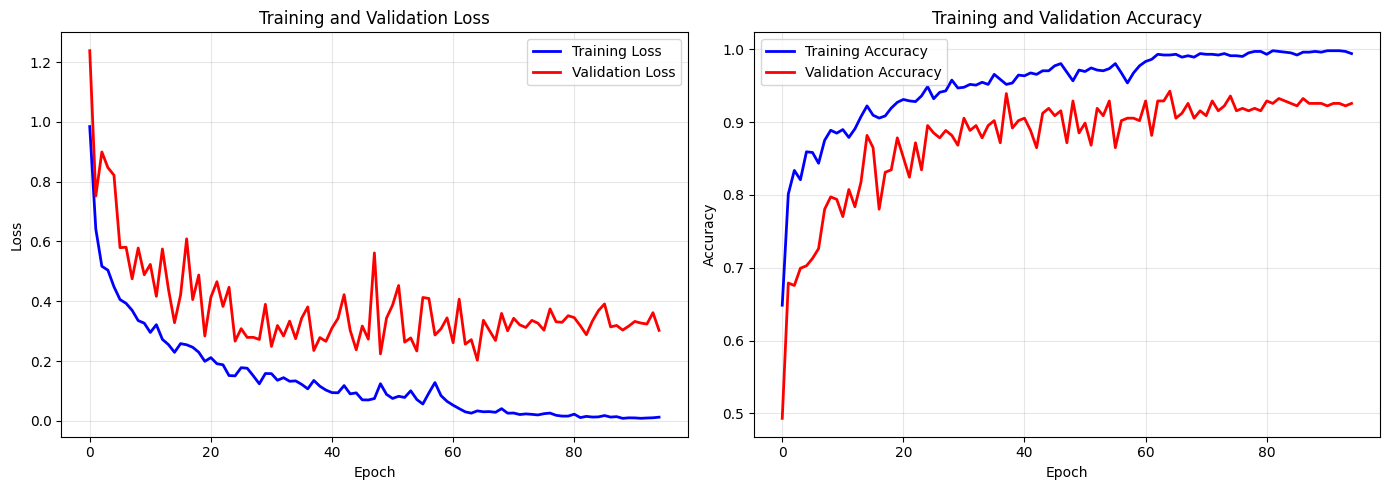


✓ Training curves saved
Final Training Loss: 0.0122
Final Validation Loss: 0.3026
Final Training Accuracy: 0.9941
Final Validation Accuracy: 0.9257


In [ ]:
# CELL 15: Plot Training Curves
if len(train_losses) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curves
    axes[0].plot(train_losses, label='Training Loss', color='blue', linewidth=2)
    axes[0].plot(val_losses, label='Validation Loss', color='red', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy curves
    axes[1].plot(train_accs, label='Training Accuracy', color='blue', linewidth=2)
    axes[1].plot(val_accs, label='Validation Accuracy', color='red', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    os.makedirs(os.path.join(PROCESSED_DIR, 'figures'), exist_ok=True)
    plt.savefig(os.path.join(PROCESSED_DIR, 'figures', 'training_curves.png'), dpi=300)
    plt.show()
    
    print(f"\n✓ Training curves saved")
    print(f"Final Training Loss: {train_losses[-1]:.4f}")
    print(f"Final Validation Loss: {val_losses[-1]:.4f}")
    print(f"Final Training Accuracy: {train_accs[-1]:.4f}")
    print(f"Final Validation Accuracy: {val_accs[-1]:.4f}")
else:
    print(" Training hasn't been run yet.")

In [15]:
# CELL 15.5: Evaluation du modele sur le test set

print("=" * 60)
print("EVALUATION SUR LE TEST SET")
print("=" * 60)

# Evaluation
y_true, y_pred = evaluate_model(model, test_loader, device)

# Calcul des metriques
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Overall Accuracy (OA):    {accuracy:.4f}")
print(f"Weighted F1-score:        {f1:.4f}")

# Afficher les classes uniques
unique_classes = np.unique(y_true)
print(f"Classes presentes: {unique_classes}")

# Sauvegarder les predictions pour la cellule suivante
print("Predictions sauvegardees dans y_true et y_pred")

EVALUATION SUR LE TEST SET


NameError: name 'evaluate_model' is not defined

# 16: Confusion Matrix

In [5]:
# CELL 16: Confusion Matrix
# Calculate confusion matrix
cm = confusion_matrix(labels, preds)

# Normalize by row 
cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Normalized Confusion Matrix - MCTNet', fontsize=14)
plt.tight_layout()

# Save
os.makedirs(os.path.join(PROCESSED_DIR, 'figures'), exist_ok=True)
plt.savefig(os.path.join(PROCESSED_DIR, 'figures', 'confusion_matrix_normalized.png'), dpi=300)
plt.show()

print(f"\n✓ Confusion matrix saved")

NameError: name 'confusion_matrix' is not defined

# 17: Save Model

In [ ]:
# CELL 17: Save Model
model_path = os.path.join(PROCESSED_DIR, 'mctnet_model.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'metrics': {
        'oa': oa,
        'kappa': kappa,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    },
    'class_names': metadata['crop_names'],
    'label_to_idx': label_to_idx,
    'idx_to_label': idx_to_label,
    'hyperparameters': {
        'd_model': 64,
        'nhead': 4,
        'n_stages': 3,
        'kernel_sizes': [3, 5, 7],
        'dropout': 0.1
    }
}, model_path)

print(f"\n Model saved to: {model_path}")
print("\n" + "="*70)
print("PART 5 COMPLETE!")
print("="*70)


✅ Model saved to: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed\mctnet_model.pth

PART 5 COMPLETE!
